# Module 10, Recitation 1: Integer Optimization (Gurobi)

Today's recitation introduces integer optimization using a case study in vaccine allocations.

First, let's import the packages we need:

<a href="https://colab.research.google.com/github/yuri-spizhovyi-mit/ET6-ML/blob/main/module_10/mod10_rec1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>`


In [ ]:
%pip install pandas
%pip install numpy
%pip install seaborn
%pip install geopandas
%pip install matplotlib
%pip install pulp --index-url=https://pypi.org/simple 

import pulp
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# For our visualizations
import re
import seaborn as sns
import geopandas as gpd
from PIL import Image
from matplotlib.patches import Patch, Circle

!git clone https://github.com/yuri-spizhovyi-mit/ET6-ML.git
%cd ET6-ML/module_10

In [ ]:
import os, zipfile, shutil

filename = "data.zip"
extract_path = "data"

# Clean old folder if needed
if os.path.exists(extract_path):
    shutil.rmtree(extract_path)
os.makedirs(extract_path, exist_ok=True)

# Extract
with zipfile.ZipFile(filename, "r") as zip_ref:
    zip_ref.extractall(extract_path)

# --- Auto-fix nested "Data/Data" structure ---
nested = os.path.join(extract_path, "data")
if os.path.exists(nested):
    for item in os.listdir(nested):
        shutil.move(os.path.join(nested, item), extract_path)
    shutil.rmtree(nested)

print("✅ Extracted and flattened successfully!")

### COVID Vaccine Allocation
**Strategic planning decision**: where to open facilities to serve demand for vaccines

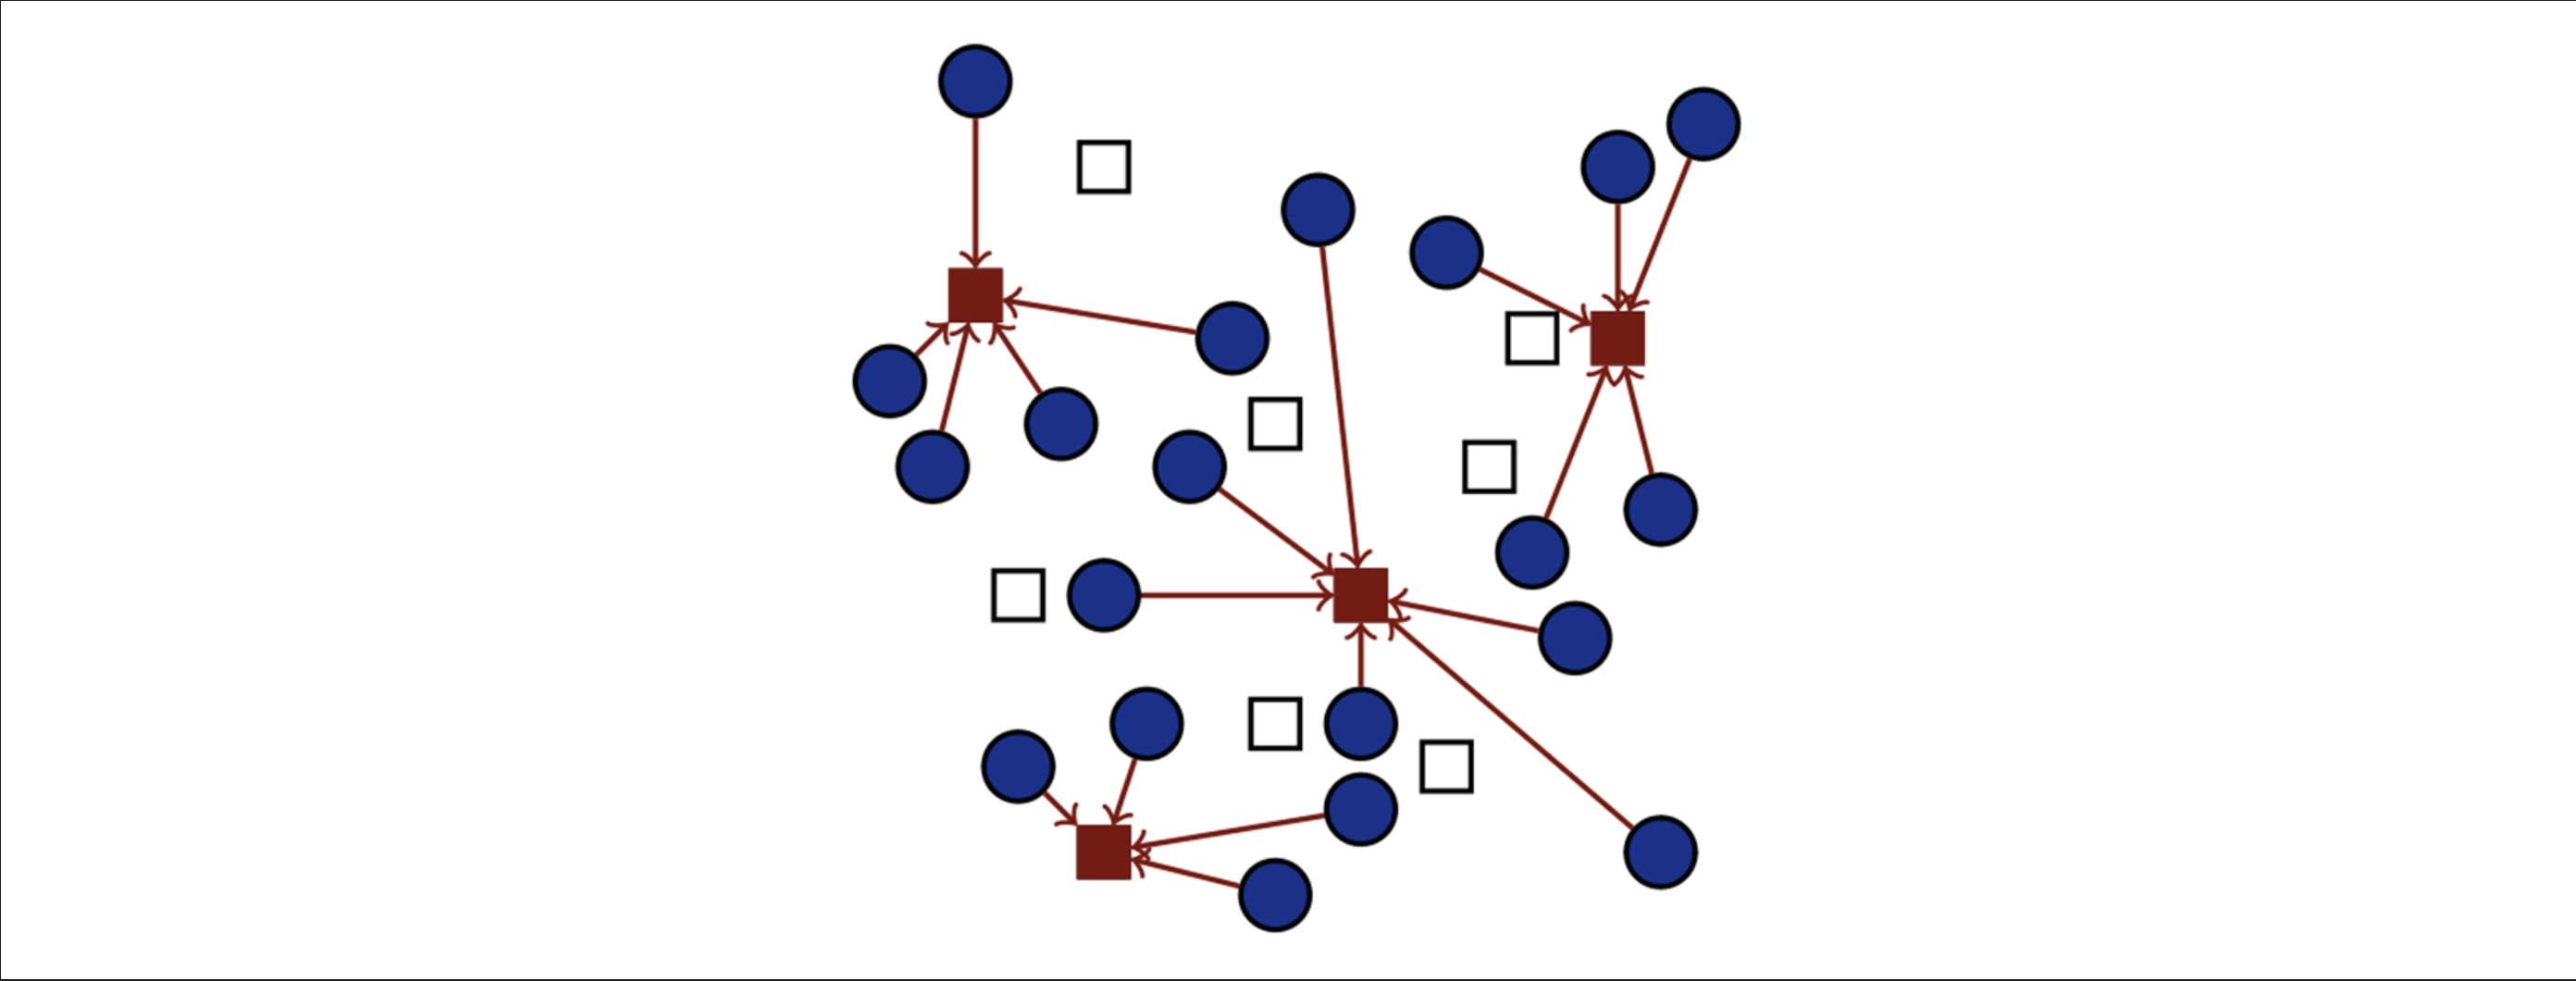

- Integrated operations and planning by jointly opening facilities and assigning demand to facilities
- Objective of serving as many people as possible
- Objective of minimizing travel distance to reach facilities
- Constraints from maximum travel distance, limited facility capacities, limited budget of facilities, etc.
- Linking constraint: customers can only be served from selected facilities

## Read in the data

In [ ]:
dist_df = pd.read_csv("data/counties_distances.csv")

# Extract the numeric matrix (excluding the first column)
dist = dist_df.iloc[:, 1:].to_numpy().T  # Transpose the matrix

# Get dimensions
n = dist.shape[1]
m = dist.shape[0]
print("Number of facilities = ", n)
print("Number of counties = ", m)

Number of facilities =  249
Number of counties =  3141


In [ ]:
compatibility = dist >= 0

In [ ]:
# Read in the cleaned population data
d = pd.read_csv("data/county_pop_clean.csv")

# Compute the total population from specified columns
d["pop"] = d["pop09"] + d["pop1049"] + d["pop59"] + d["pop69"] + d["pop79"] + d["pop89"]

# Assign to demand
demand = d["pop"]
demand

0         1655
1         3046
2       200784
3        15258
4          610
         ...  
3136     31172
3137     15077
3138     16009
3139      6140
3140      5344
Name: pop, Length: 3141, dtype: int64

# Model Formulation


**Decision variables**

$$
\begin{align*}
x_{j} &=
\begin{cases}
1 \quad \text{if facility $j$ is built} \\
0 \quad \text{otherwise}
\end{cases} \\
y_{ij} &= \text{number of vaccinations from neighborhood $i$ to facility $j$} \\
z_i &= \text{unmet demand in neighborhood $i$} \\
    \end{align*}
$$


**Objective -** Minimize travel distance plus the cost of unmet demand
$$
\begin{align*}
\min \:  \sum_{j=1}^n \sum_{i=1}^m t_{ij} y_{ij} +  \sum_{i=1}^m u_{i} z_{i}  
\end{align*}
$$

**Constraints**

The number of people assigned to each facility is less than its capacity
$$
\begin{align*}
\sum_{i=1}^m y_{ij} \leq C_j \quad \forall j=1,\ldots,n
\end{align*}
$$

Auxiliary variable to track unmet demand  in each neighborhood
$$
\begin{align*}
\sum_{i=1}^m y_{ij} + z_i = D_i \quad \forall i = 1,\ldots,m
\end{align*}
$$

People cannot get vaccinated in far-away facilities
$$
\begin{align*}
y_{ij}=0 \quad \forall j=1,\ldots,n, \forall i \notin \mathcal{C}_j
\end{align*}
$$

Number of facilities opened does not exceed budget $B$
$$
\begin{align*}
\sum_{j=1}^n x_j \leq B
\end{align*}
$$

People cannot be assigned to a facility that is not built (Big-$M$ constraint)
$$
\begin{align*}
y_{ij} \leq M x_j \quad \forall i = 1,\ldots,m, \forall j=1,\ldots,n
\end{align*}
$$

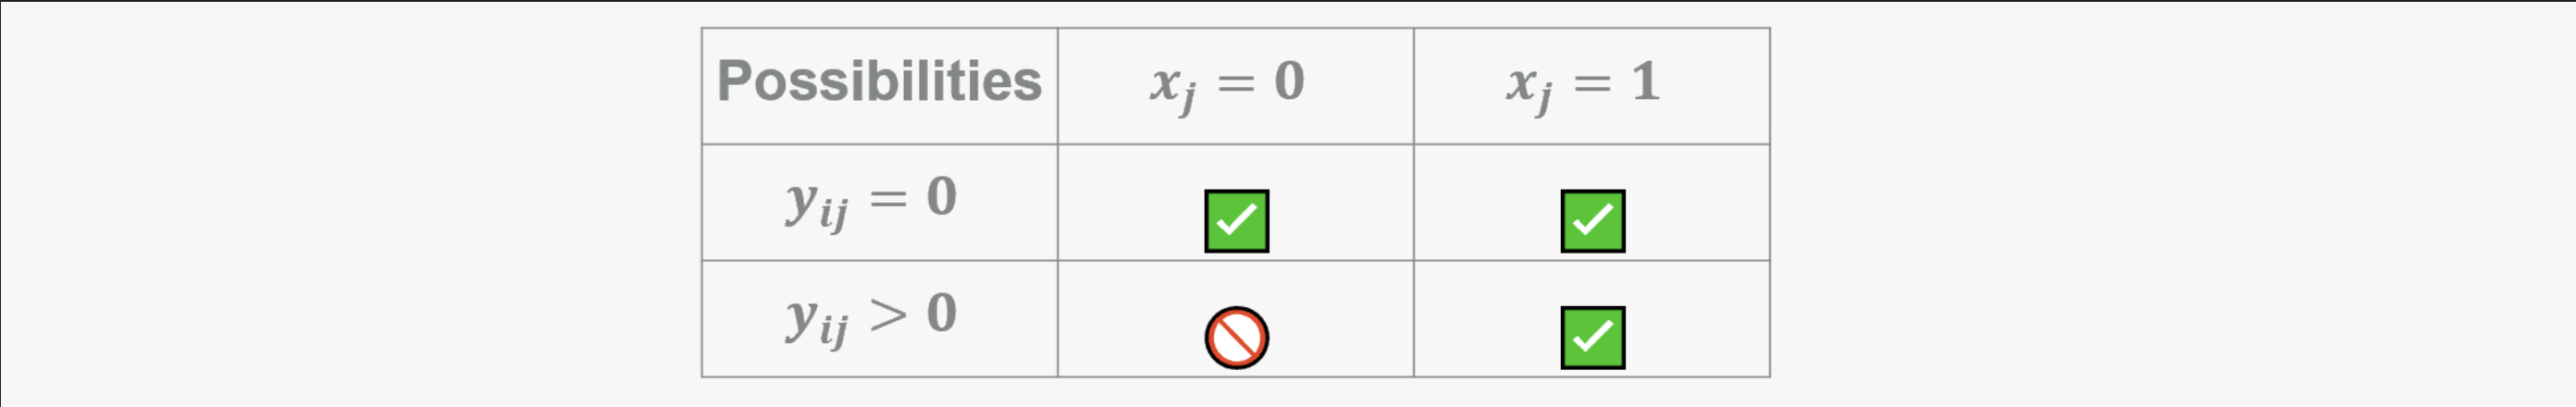

Variable bounds
$$
\begin{align*}
x_{ij} &\in \{0,1\}\quad \forall i = 1,\ldots,m, \forall j=1,\ldots,n\\
y_{ij} & \geq 0 \quad \forall i = 1,\ldots,m, \forall j=1,\ldots,n\\
z_i &\geq 0  \quad \forall i = 1,\ldots,m
\end{align*}
$$

Before we write the model, we need to think about what solver we will use. In the past, you may have used GLPK (free and open-source) or a commercial solver like Gurobi (which requires a license, but a [free academic license](https://www.gurobi.com/academia/academic-program-and-licenses/) can be obtained if you are affiliated with a university). To see the solvers that are available to you right now, run the following:

In [ ]:
pulp.listSolvers(onlyAvailable=True)

['GUROBI_CMD', 'PULP_CBC_CMD']

If you have a commercial solver like Gurobi available, it's best to use it as they are **much** faster than the freely available GLPK at problems with integer and binary variables. However, for today's purposes, you can use GLPK.

In [ ]:
def facilityLocationModel(
    B, capacity, u, TIME_LIMIT, OPTIMALITY_GAP, verbose, dist, demand, compatibility
):
    m = len(demand)  # number of demand points
    n = len(capacity)  # number of facilities

    # Create model
    model = pulp.LpProblem("facilityLocation", pulp.LpMinimize)

    # Variables
    x = pulp.LpVariable.dicts("x", (j for j in range(n)), cat="Binary")
    y = pulp.LpVariable.dicts(
        "y", ((i, j) for i in range(m) for j in range(n)), lowBound=0, cat="Continuous"
    )
    z = pulp.LpVariable.dicts("z", (i for i in range(m)), lowBound=0, cat="Continuous")

    # Objective
    model += pulp.lpSum(
        dist[i][j] * y[i, j] for i in range(m) for j in range(n)
    ) + 1000 * pulp.lpSum(u[i] * z[i] for i in range(m))

    # Constraints

    # Total facilities used
    model += pulp.lpSum(x[j] for j in range(n)) <= B

    # Capacity limits
    for j in range(n):
        model += pulp.lpSum(y[i, j] for i in range(m)) <= capacity[j]

    # Big-M: Flow only to open facilities and only up to min(capacity, demand)
    for i in range(m):
        for j in range(n):
            bigM = min(
                capacity[j], demand[i]
            )  # Set big-M to be *as small as possible* while ensuring constraint always satisfied when x[j]=1
            model += y[i, j] <= bigM * x[j]

    # Demand satisfaction
    for i in range(m):
        model += pulp.lpSum(y[i, j] for j in range(n)) + z[i] == demand[i]

    # Compatibility constraints
    for i in range(m):
        for j in range(n):
            if not compatibility[i][j]:
                model += y[i, j] == 0.0
                model += y[i, j] == 0.0

    # Optimize
    model.solve(
        pulp.PULP_CBC_CMD(msg=True, timeLimit=30)
    )  # CHANGE THE SOLVER NAME HERE IF DESIRED

    # Extract values after solving
    xOPT = {j: pulp.value(x[(j)]) for j in range(n)}
    yOPT = {(i, j): pulp.value(y[(i, j)]) for i in range(m) for j in range(n)}
    zOPT = {i: pulp.value(z[i]) for i in range(m)}

    x_df = pd.DataFrame({"id": np.arange(1, n + 1), "facilities": dist_df["Facility"]})
    x_df["selected"] = xOPT
    x_df["capacity"] = capacity

    z_df = pd.DataFrame(
        {"id": np.arange(1, m + 1), "counties": dist_df.columns[1:], "demand": demand}
    )
    z_df["unmet"] = zOPT

    return xOPT, yOPT, zOPT, x_df, z_df

Now we can set the facility budget and solve an instance of the problem! Run the cell below and we can see the output log for how the algorithm progresses.

In [ ]:
# Problem parameters
B = 30  # Facility budget
V = 1500000 * 30 * 3  # Total vaccines
capacity = np.full(n, V / B)  # Vaccine capacity per facility
u = np.full(m, 10.0)  # Penalty for unmet demand

# Optimization parameters
TIME_LIMIT = 600
OPTIMALITY_GAP = 1e-3
verbose = True

# Build and solve the optimization model
xOPT_B30, yOPT_B30, zOPT_B30, x_df_B30, z_df_B30 = facilityLocationModel(
    B, capacity, u, TIME_LIMIT, OPTIMALITY_GAP, verbose, dist, demand, compatibility
)

Set parameter Username
Set parameter LicenseID to value 2695571
Set parameter TimeLimit to value 30
Set parameter LogFile to value "gurobi.log"
Using license file /Users/vasstou/gurobi.lic
Academic license - for non-commercial use only - expires 2026-08-14

Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (mac64[arm] - Darwin 24.6.0 24G84)
Copyright (c) 2025, Gurobi Optimization, LLC

Read LP format model from file /var/folders/jw/mzldzx895v9180t6dv1vz9qw0000gp/T/3557628fc0cc404e8c76e4d189b3c6fa-pulp.lp
Reading time = 1.78 seconds
OBJ: 2310758 rows, 785499 columns, 4657084 nonzeros

Using Gurobi shared library /Library/gurobi1203/macos_universal2/lib/libgurobi120.dylib

CPU model: Apple M4 Pro
Thread count: 12 physical cores, 12 logical processors, using up to 12 threads

Non-default parameters:
TimeLimit  30

Optimize a model with 2310758 rows, 785499 columns and 4657084 nonzeros
Model fingerprint: 0x689e3ede
Variable types: 785250 continuous, 249 integer (249 binary)
Coefficient stat

Let's see how increasing the budget of facilities impacts our model.

In [ ]:
# Increase the budget of facilities
B = 100
capacity = np.full(n, V / B)

# Build and solve the optimization model
xOPT_B100, yOPT_B100, zOPT_B100, x_df_B100, z_df_B100 = facilityLocationModel(
    B, capacity, u, TIME_LIMIT, OPTIMALITY_GAP, verbose, dist, demand, compatibility
)

Set parameter Username
Set parameter LicenseID to value 2695571
Set parameter TimeLimit to value 30
Set parameter LogFile to value "gurobi.log"
Using license file /Users/vasstou/gurobi.lic
Academic license - for non-commercial use only - expires 2026-08-14

Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (mac64[arm] - Darwin 24.6.0 24G84)
Copyright (c) 2025, Gurobi Optimization, LLC

Read LP format model from file /var/folders/jw/mzldzx895v9180t6dv1vz9qw0000gp/T/69a3bbf0c2764baf9d09c6d30633bf71-pulp.lp
Reading time = 1.75 seconds
OBJ: 2310758 rows, 785499 columns, 4657084 nonzeros

Using Gurobi shared library /Library/gurobi1203/macos_universal2/lib/libgurobi120.dylib

CPU model: Apple M4 Pro
Thread count: 12 physical cores, 12 logical processors, using up to 12 threads

Non-default parameters:
TimeLimit  30

Optimize a model with 2310758 rows, 785499 columns and 4657084 nonzeros
Model fingerprint: 0xa50e7075
Variable types: 785250 continuous, 249 integer (249 binary)
Coefficient stat

## Visualizations

So it appears the solution with 100 facilities is slightly better in terms of objective value. Let's visualize the facilities built to get a better understanding of the solutions.

We start by adding latitude and longitude columns to `x_df_B30`, which contains the list of selected and unselected facilitiies for our solution.

In [ ]:
def convertFacilities(facilities):
    # Read geographic data
    facilities_geo = pd.read_csv("data/selected_centers.csv")

    # Extract latitude and longitude from the 'county_geolocation' column
    lat = []
    long = []

    for coord in facilities_geo["county_geolocation"]:
        coord = coord.strip("()")
        lat_val, long_val = coord.split(",")
        lat.append(float(lat_val))
        long.append(float(long_val))

    # Add latitude and longitude to the facilities DataFrame
    facilities["latitude"] = lat
    facilities["longitude"] = long

    # Filter facilities to only those with longitude > -130
    facilities_filtered = facilities[facilities["longitude"] > -130]
    facilities_filtered.loc[:, "selected"] = (
        facilities_filtered["selected"].round(0).astype(int)
    )

    return facilities_filtered

In [ ]:
# Create the facilities dataframe for B=30
facilities_B30 = convertFacilities(x_df_B30)

Next, we'll do some preprocessing of our county data to get it ready for visualization.

In [ ]:
# Load raw county population data
county_discard = pd.read_csv("data/county-pop.csv")
county_discard["county"] = (
    county_discard["CTYNAME"].str.lower().str.replace(" county", "", regex=False)
)
county_discard["state"] = county_discard["STNAME"].str.lower()

# Load cleaned county population data
county_clean = pd.read_csv("data/county_pop_clean.csv")

# Join on specific columns (as in the R code)
join_cols = ["pop09", "pop59", "pop69", "pop79", "pop89"]
county = pd.merge(county_clean, county_discard, on=join_cols, how="inner")

# Drop unnecessary columns
cols_to_drop = [
    "pop09",
    "pop1049",
    "pop59",
    "pop69",
    "pop79",
    "pop89",
    "pop19",
    "pop29",
    "pop39",
    "pop49",
    "index",
    "STATE",
    "COUNTY",
]
county = county.drop(columns=cols_to_drop)

# Rename columns
county = county.rename(
    columns={
        "state_x": "State_code",
        "county_state": "County_code",
        "CTYNAME": "County_Name",
        "STNAME": "State_Name",
        "state_y": "state",
    }
)

# Apply county name corrections
county_replacements = {
    "dekalb": "dekalb",
    "st. clair": "st. clair",
    "st. francis": "st. francis",
    "st. john": "st. john",
    "st. bernard": "st. bernard",
    "st. bernard parish": "st. bernard",
    "st. charles": "st. charles",
    "st. charles parish": "st. charles",
    "st. croix": "st. croix",
    "st. francois": "st. francois",
    "st. helena": "st. helena",
    "st. helena parish": "st. helena",
    "st. james": "st. james",
    "st. james parish": "st. james",
    "st. johns": "st. johns",
    "st. john the baptist parish": "st. john the baptist",
    "st. martin parish": "st. martin",
    "st. louis": "st. louis",
    "st. louis city": "st. louis",
    "st. mary parish": "st. mary",
    "st. mary's": "st. mary's",
    "st. tammany parish": "st. tammany",
    "st. lawrence": "st. lawrence",
    "st. lucie": "st. lucie",
    "ste. genevieve": "ste. genevieve",
    "st. johns county": "st. johns",
    "dupage": "dupage",
    "laporte": "laporte",
    "st. joseph": "st. joseph",
    "allen parish": "allen",
    "caddo parish": "caddo",
    "acadia parish": "acadia",
    "ascension parish": "ascension",
    "avoyelles parish": "avoyelles",
    "beauregard parish": "beauregard",
    "bossier parish": "bossier",
    "assumption parish": "assumption",
    "bienville parish": "bienville",
    "calcasieu parish": "calcasieu",
    "catahoula parish": "catahoula",
    "concordia parish": "concordia",
    "evangeline parish": "evangeline",
    "ouachita parish": "ouachita",
    "orleans parish": "orleans",
    "red river parish": "red river",
    "sabine parish": "sabine",
    "richland parish": "richland",
    "union parish": "union",
    "vermilion parish": "vermilion",
    "vernon parish": "vernon",
    "washington parish": "washington",
    "webster parish": "webster",
    "madison parish": "madison",
    "livingston parish": "livingston",
    "lincoln parish": "lincoln",
    "lasalle parish": "lasalle",
    "lafayette parish": "lafayette",
    "jefferson parish": "jefferson",
    "jefferson davis parish": "jefferson davis",
    "jackson parish": "jackson",
    "grant parish": "grant",
    "franklin parish": "franklin",
    "de soto parish": "de soto",
    "claiborne parish": "claiborne",
    "cameron parish": "cameron",
    "caldwell parish": "caldwell",
    "iberia parish": "iberia",
    "iberville parish": "iberville",
    "plaquemines parish": "plaquemines",
    "tangipahoa parish": "tangipahoa",
    "natchitoches parish": "natchitoches",
    "rapides parish": "rapides",
    "lafourche parish": "lafourche",
    "morehouse parish": "morehouse",
    "tensas parish": "tensas",
    "winn parish": "winn",
    "terrebonne parish": "terrebonne",
    "st. landry parish": "st. landry",
    "virginiabeachcity": "virginia beach",
    "westcarroll": "west carroll",
    "west feliciana parish": "west feliciana",
    "east feliciana parish": "east feliciana",
    "east baton rouge parish": "east baton rouge",
    "west baton rouge parish": "west baton rouge",
    "pointe coupee parish": "pointe coupee",
    "princegeorges": "prince georges",
    "newport news city": "newport news",
    "virginia beach city": "virginia beach",
    "eastcarroll": "east carroll",
    "eastfeliciana": "east feliciana",
    "east carroll parish": "east carroll",
    "west carroll parish": "west carroll",
    "do<f1>a ana": "dona ana",
    "suffolk city": "suffolk",
    "norfolk city": "norfolk",
    "hampton city": "hampton",
    "williamsburg city": "williamsburg",
    "waynesboro city": "waynesboro",
    "williamsburg city virginia": "williamsburg",
    "alexandria city": "alexandria",
    "bristol city": "bristol",
    "buena vista city": "buena vista",
    "charlottesville city": "charlottesville",
    "chesapeake city": "chesapeake",
    "colonial heights city": "colonial heights",
    "covington city": "covington",
    "danville city": "danville",
    "emporia city": "emporia",
    "fairfax city": "fairfax",
    "falls church city": "falls church",
    "franklin city": "franklin",
    "fredericksburg city": "fredericksburg",
    "galax city": "galax",
    "harrisonburg city": "harrisonburg",
    "hopewell city": "hopewell",
    "lexington city": "lexington",
    "lynchburg city": "lynchburg",
    "manassas city": "manassas",
    "manassas park city": "manassas park",
    "martinsville city": "martinsville",
    "norton city": "norton",
    "petersburg city": "petersburg",
    "poquoson city": "poquoson",
    "portsmouth city": "portsmouth",
    "radford city": "radford",
    "richmond city": "richmond",
    "roanoke city": "roanoke",
    "salem city": "salem",
    "staunton city": "staunton",
    "waynesboro city": "waynesboro",
    "winchester city": "winchester",
    "baltimore city": "baltimore",
}
county["county"] = county["county"].replace(county_replacements)

# Add Yellowstone National entry
new_entry = county[county["county"] == "yellowstone"].copy()
new_entry["County_Name"] = "Yellowstone National"
new_entry["county"] = "yellowstone"
county = pd.concat([county, new_entry], ignore_index=True)

# Add combined identifier
county["statecounty"] = county["state"] + " " + county["county"]

# Filter out non-continental states
county_continental = county[~county["state"].isin(["alaska", "hawaii"])].copy()

# Import
counties = gpd.read_file("data/cb_2018_us_county_500k/cb_2018_us_county_500k.shp")
counties = counties[~counties.STATEFP.isin(["72", "69", "60", "66", "78"])]
counties = counties[~counties.STATEFP.isin(["02", "15"])]  # Alaska and Hawaii
counties = counties.set_index("GEOID")

states = gpd.read_file("data/cb_2018_us_state_500k/cb_2018_us_state_500k.shp")
states = states[~states.STATEFP.isin(["72", "69", "60", "66", "78"])]
states = states[~states.NAME.isin(["Alaska", "Hawaii"])]
states = states.rename(columns={"geometry": "geometry_state", "NAME": "NAME_state"})
states_bare = states[["STATEFP", "NAME_state"]]

# Add STATEFP to county
county_withstatefp = county.merge(
    states_bare, left_on="State_Name", right_on="NAME_state", how="inner"
)
county_withstatefp

# #Add state names to counties
counties_withstatename = counties.merge(
    states_bare, left_on="STATEFP", right_on="STATEFP", how="left"
)
counties_withstatename["NAME"] = counties_withstatename["NAME"].str.lower()

# #Dona ana name
import re

counties_withstatename["NAME"] = counties_withstatename["NAME"].str.replace(
    r"do.+a ana", "dona ana", regex=True
)

We'll set a few design parameters for our visualization, namely colors.

In [ ]:
edge_color = "#30011E"
background_color = "#fafafa"

sns.set_style(
    {
        "font.family": "serif",
        "figure.facecolor": background_color,
        "axes.facecolor": background_color,
    }
)

min_r, min_g, min_b = 23, 7, 255
max_r, max_g, max_b = 255, 255, 255


def rgb2hex(r, g, b):
    return "#{:02x}{:02x}{:02x}".format(r, g, b)


def create_color(counties_demand, log_demand_min, log_demand_max):
    colors = []

    for i, row in counties_demand.iterrows():
        myval = max(0, row.value)
        fraction = 1 - (myval - log_demand_min) / (log_demand_max - log_demand_min)
        r, g, b = (
            int(round(min_r + (max_r - min_r) * fraction, 0)),
            int(round(min_g + (max_g - min_g) * fraction, 0)),
            int(round(min_b + (max_b - min_b) * fraction, 0)),
        )
        c = rgb2hex(r, g, b)
        colors.append(c)

    return colors

In [ ]:
def visualizeMap(z_df, facilities_filtered):
    # Find min and max log demand to set colors
    county["demand"] = z_df["demand"]
    county["unmet"] = z_df["unmet"]
    county["log_demand"] = county["demand"].apply(lambda x: np.log(x) if x > 0 else 0)
    log_demand_min = county.min(axis=0)["log_demand"]
    log_demand_max = county.max(axis=0)["log_demand"]

    # Add demand and unmet needs to the county dataframe
    county_complete = county_withstatefp.merge(
        z_df, left_on=["County_code"], right_on=["counties"], how="left"
    )

    # Join county and counties
    counties_demand = counties_withstatename.merge(
        county_complete,
        left_on=["STATEFP", "NAME"],
        right_on=["STATEFP", "county"],
        how="right",
    )
    counties_demand.set_geometry("geometry")
    counties_demand["value"] = counties_demand["unmet"].apply(
        lambda x: np.log(x) if x > 0 else 0
    )
    counties_demand["color"] = create_color(
        counties_demand, log_demand_min, log_demand_max
    )

    ax = counties_demand.plot(
        edgecolor=edge_color + "55", color=counties_demand.color, figsize=(20, 20)
    )

    # Plot facilities
    mycolors = {0: "black", 1: "firebrick"}
    facilities_filtered.plot(
        ax=ax,
        x="longitude",
        y="latitude",
        kind="scatter",
        s=100,
        c=facilities_filtered["selected"].map(mycolors),
        label="Facilities",
    )

    # Remove axes
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("")
    ax.set_ylabel("")
    sns.despine(left=True, bottom=True)

    # Legend manually
    from matplotlib.lines import Line2D

    legend_elements = [
        Line2D(
            [0],
            [0],
            marker="o",
            color="w",
            label="Not selected",
            markerfacecolor="black",
            markersize=8,
        ),
        Line2D(
            [0],
            [0],
            marker="o",
            color="w",
            label="Selected",
            markerfacecolor="firebrick",
            markersize=8,
        ),
    ]
    ax.legend(
        handles=legend_elements, loc="lower center", fontsize=12, ncol=2, frameon=False
    )

    plt.tight_layout()
    plt.axis("off")
    plt.show()
    # plt.savefig("map_facilities.pdf")
    plt.close()

# Visualize vaccine distribution facilities

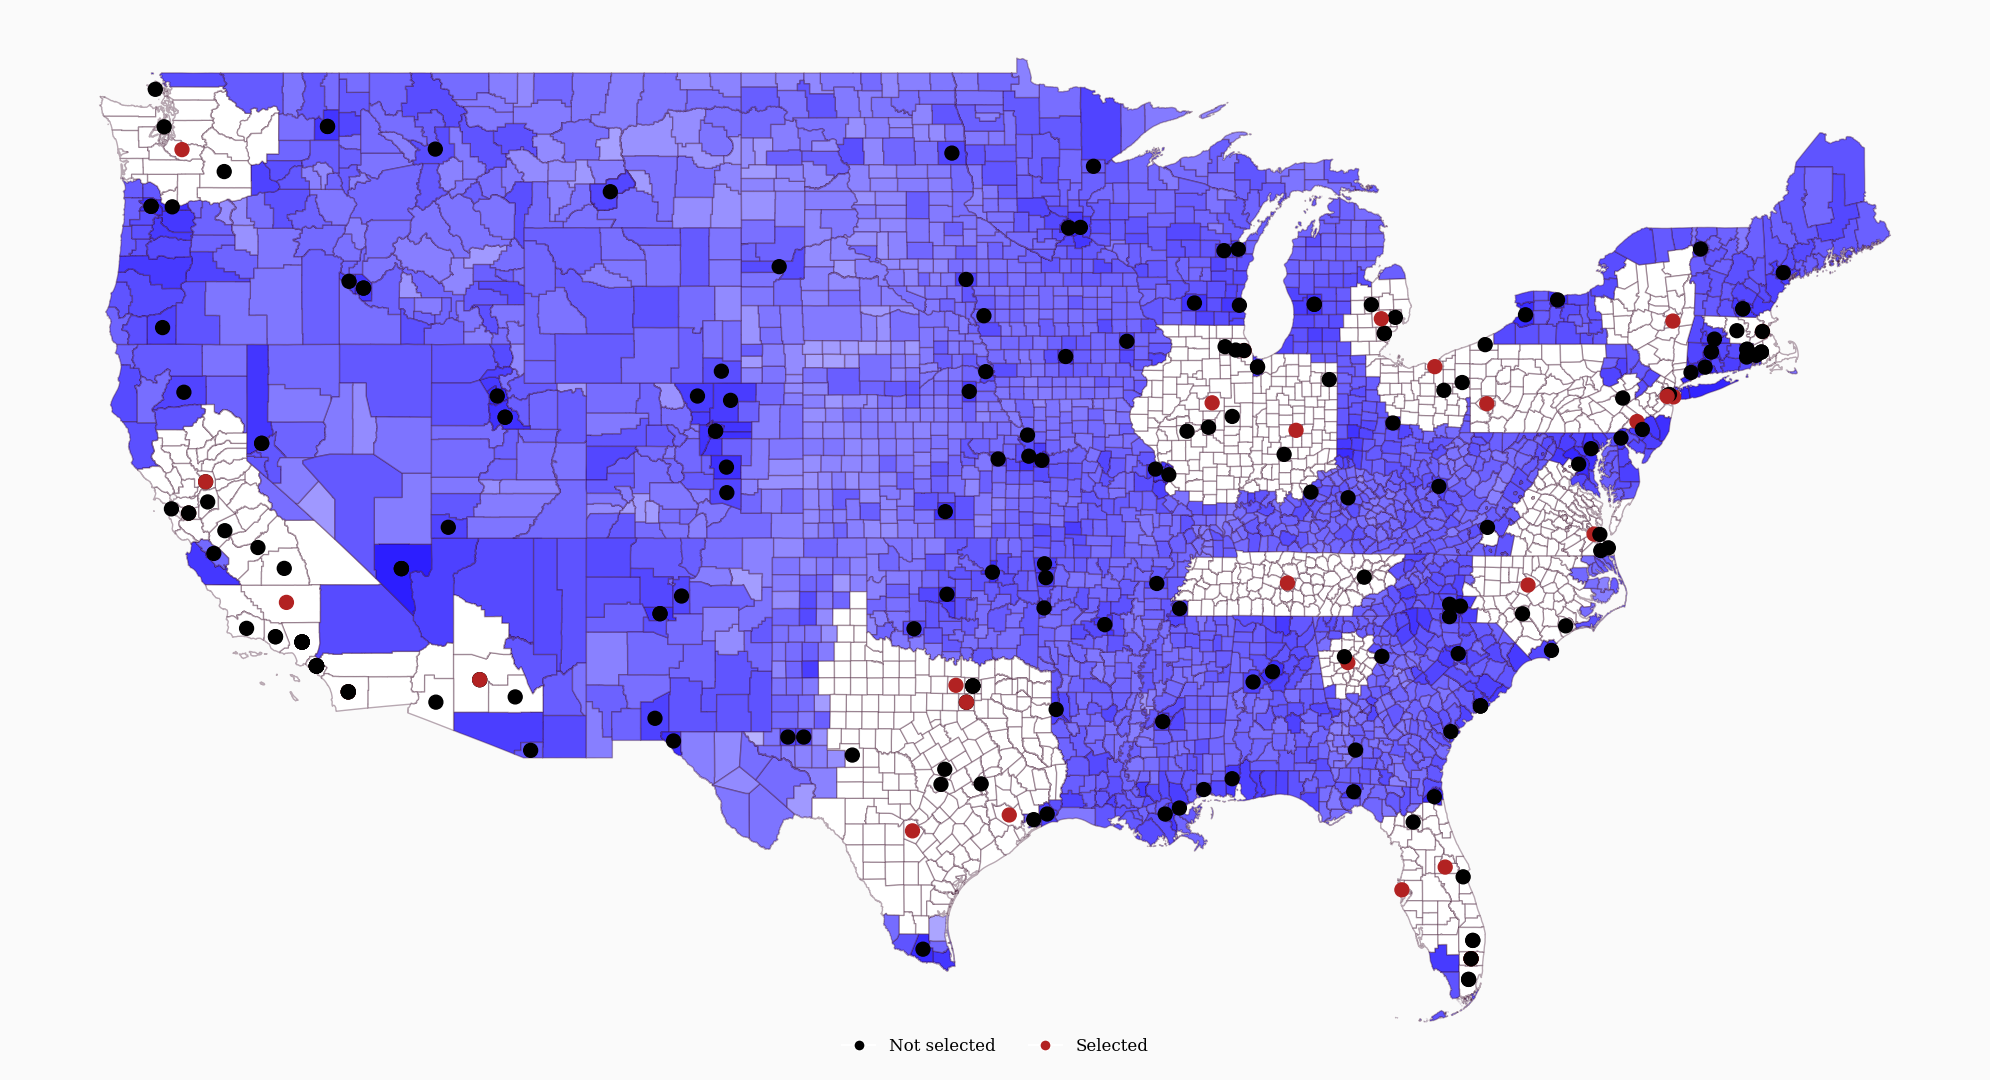

In [ ]:
visualizeMap(z_df_B30, facilities_B30)

# Visualize vaccine distribution facilities

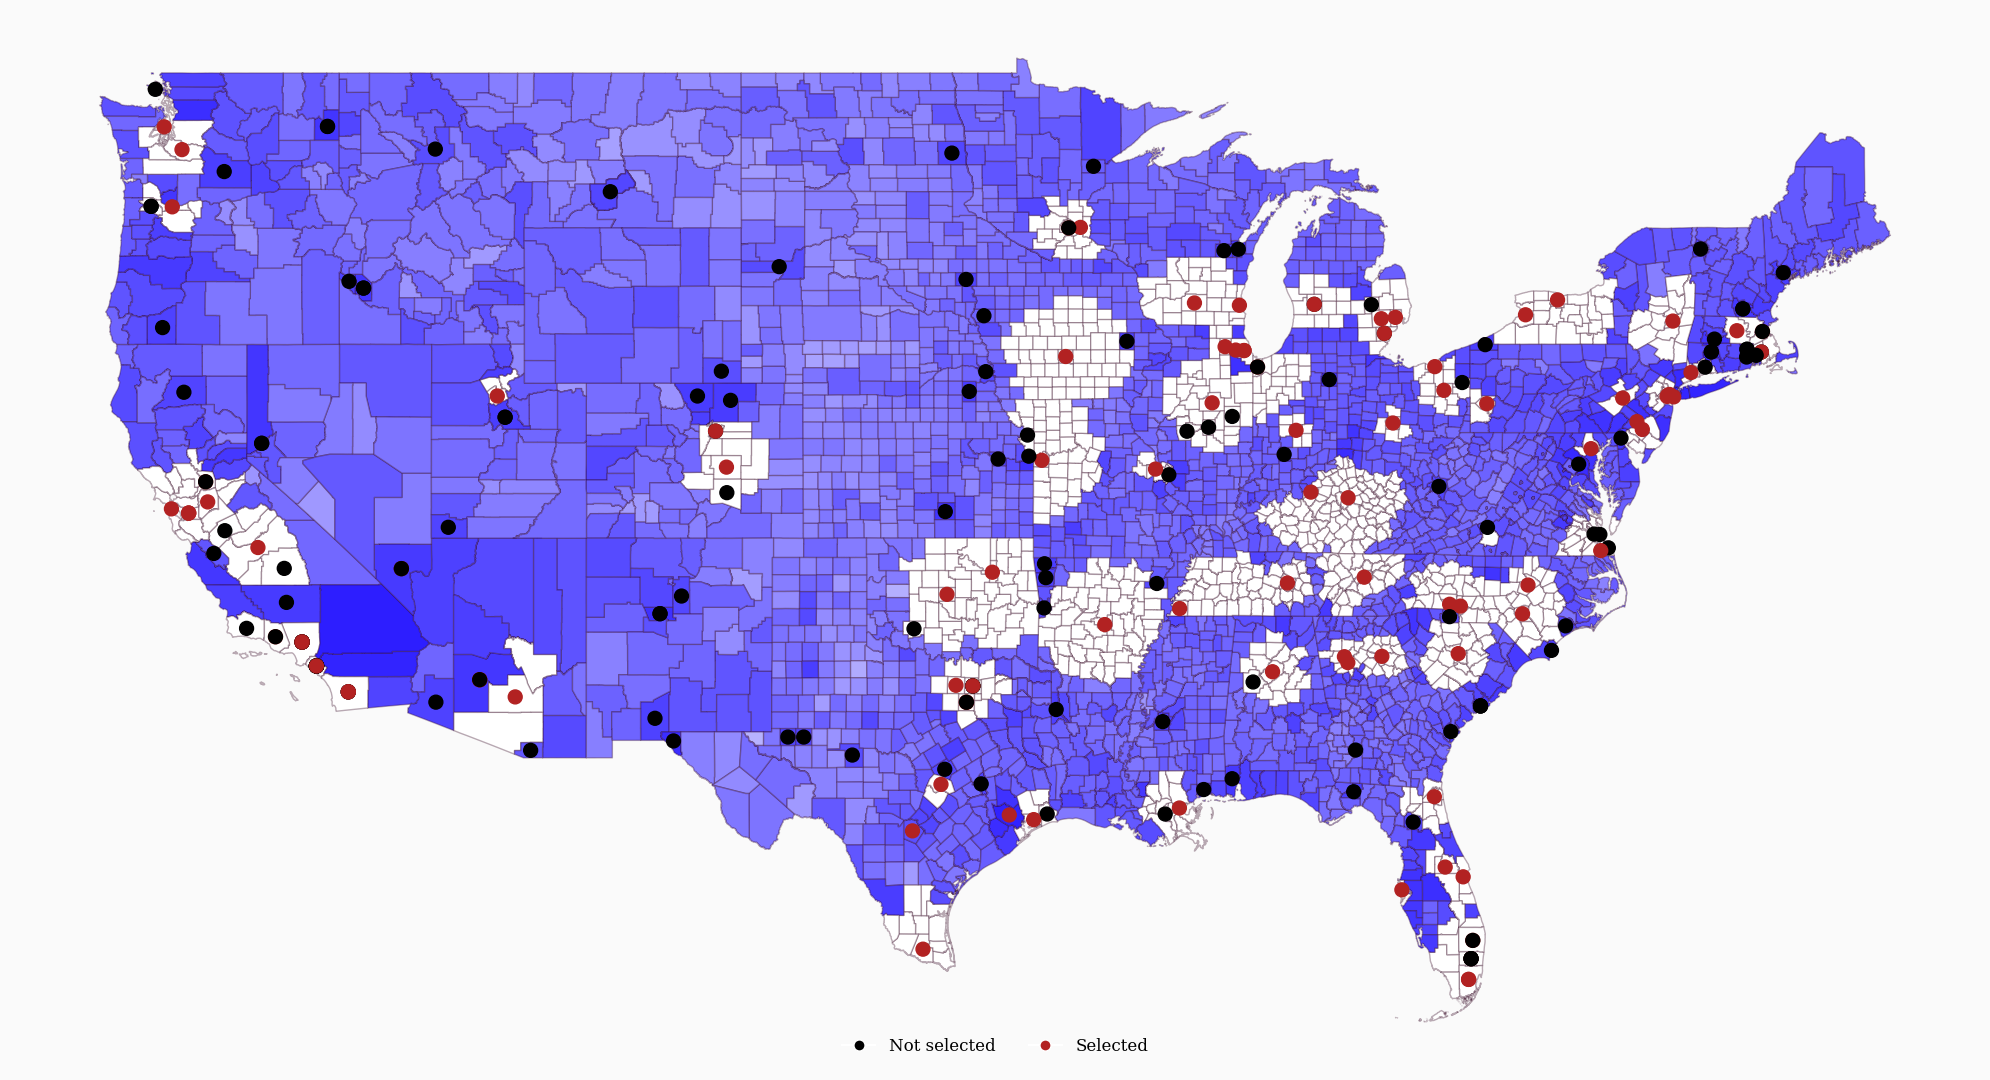

In [ ]:
facilities_B100 = convertFacilities(x_df_B100)
visualizeMap(z_df_B100, facilities_B100)

## What if we extend our model to include vaccine allocations?


**New decision variable**

$$
\begin{align*}
p_{j} &= \text{number of vaccines allocated to facility $j$} \\
    \end{align*}
$$

**Constraints**

The total number of vaccines distributed across facilities is less than the global stockpile
$$
\begin{align*}
{\color{red}\sum_{j=1}^n p_{j} \leq V}
\end{align*}
$$

The number of vaccinations must lie below the number of allocated vaccines
$$
\begin{align*}
\sum_{i=1}^m y_{ij} \leq {\color{red}p_j} \quad \forall j=1,\ldots,n
\end{align*}
$$

Vaccines can only be allocated to selected facilities ("big-M" = $V$)
$$
\begin{align*}
{\color{red} p_j \leq V x_j} \quad \forall j=1,\ldots,n
\end{align*}
$$

In [ ]:
def vaccineDistributionModel(
    B, capacity, u, TIME_LIMIT, OPTIMALITY_GAP, verbose, dist, demand, compatibility
):
    from itertools import product

    GLPK = pulp.GLPK_CMD(msg=verbose)
    m = len(demand)
    n = len(capacity)
    model = pulp.LpProblem("vaccineDistribution", pulp.LpMinimize)
    x = {j: pulp.LpVariable(f"x_{j}", 0, 1, cat="Binary") for j in range(n)}
    y = {
        (i, j): pulp.LpVariable(f"y_{i}_{j}", 0) for i, j in product(range(m), range(n))
    }
    z = {i: pulp.LpVariable(f"z_{i}", 0) for i in range(m)}
    model += pulp.lpSum(z[i] for i in range(m))
    model += pulp.lpSum(x[j] for j in range(n)) <= B
    for j in range(n):
        model += pulp.lpSum(y[(i, j)] for i in range(m)) <= capacity[j] * x[j]
    for i in range(m):
        model += pulp.lpSum(y[(i, j)] for j in range(n)) + z[i] == demand[i]
    for i, j in product(range(m), range(n)):
        if dist[i][j] > u or compatibility[i][j] == 0:
            model += y[(i, j)] == 0
    model.solve(GLPK)
    return x, y, z

In [ ]:
# Problem parameters
B = 100

# Build and solve the optimization model
xOPT_VA, yOPT_VA, zOPT_VA, x_df_VA, z_df_VA, pOPT = vaccineDistributionModel(
    B, capacity, u, TIME_LIMIT, OPTIMALITY_GAP, verbose, dist, demand, compatibility
)

Set parameter Username
Set parameter LicenseID to value 2695571
Set parameter TimeLimit to value 30
Set parameter LogFile to value "gurobi.log"
Using license file /Users/vasstou/gurobi.lic
Academic license - for non-commercial use only - expires 2026-08-14

Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (mac64[arm] - Darwin 24.6.0 24G84)
Copyright (c) 2025, Gurobi Optimization, LLC

Read LP format model from file /var/folders/jw/mzldzx895v9180t6dv1vz9qw0000gp/T/daf415c7ef604726a69821e29f781ce5-pulp.lp
Reading time = 1.30 seconds
OBJ: 1528899 rows, 785748 columns, 3093862 nonzeros

Using Gurobi shared library /Library/gurobi1203/macos_universal2/lib/libgurobi120.dylib

CPU model: Apple M4 Pro
Thread count: 12 physical cores, 12 logical processors, using up to 12 threads

Non-default parameters:
TimeLimit  30

Optimize a model with 1528899 rows, 785748 columns and 3093862 nonzeros
Model fingerprint: 0xfdc817a0
Variable types: 785499 continuous, 249 integer (249 binary)
Coefficient stat

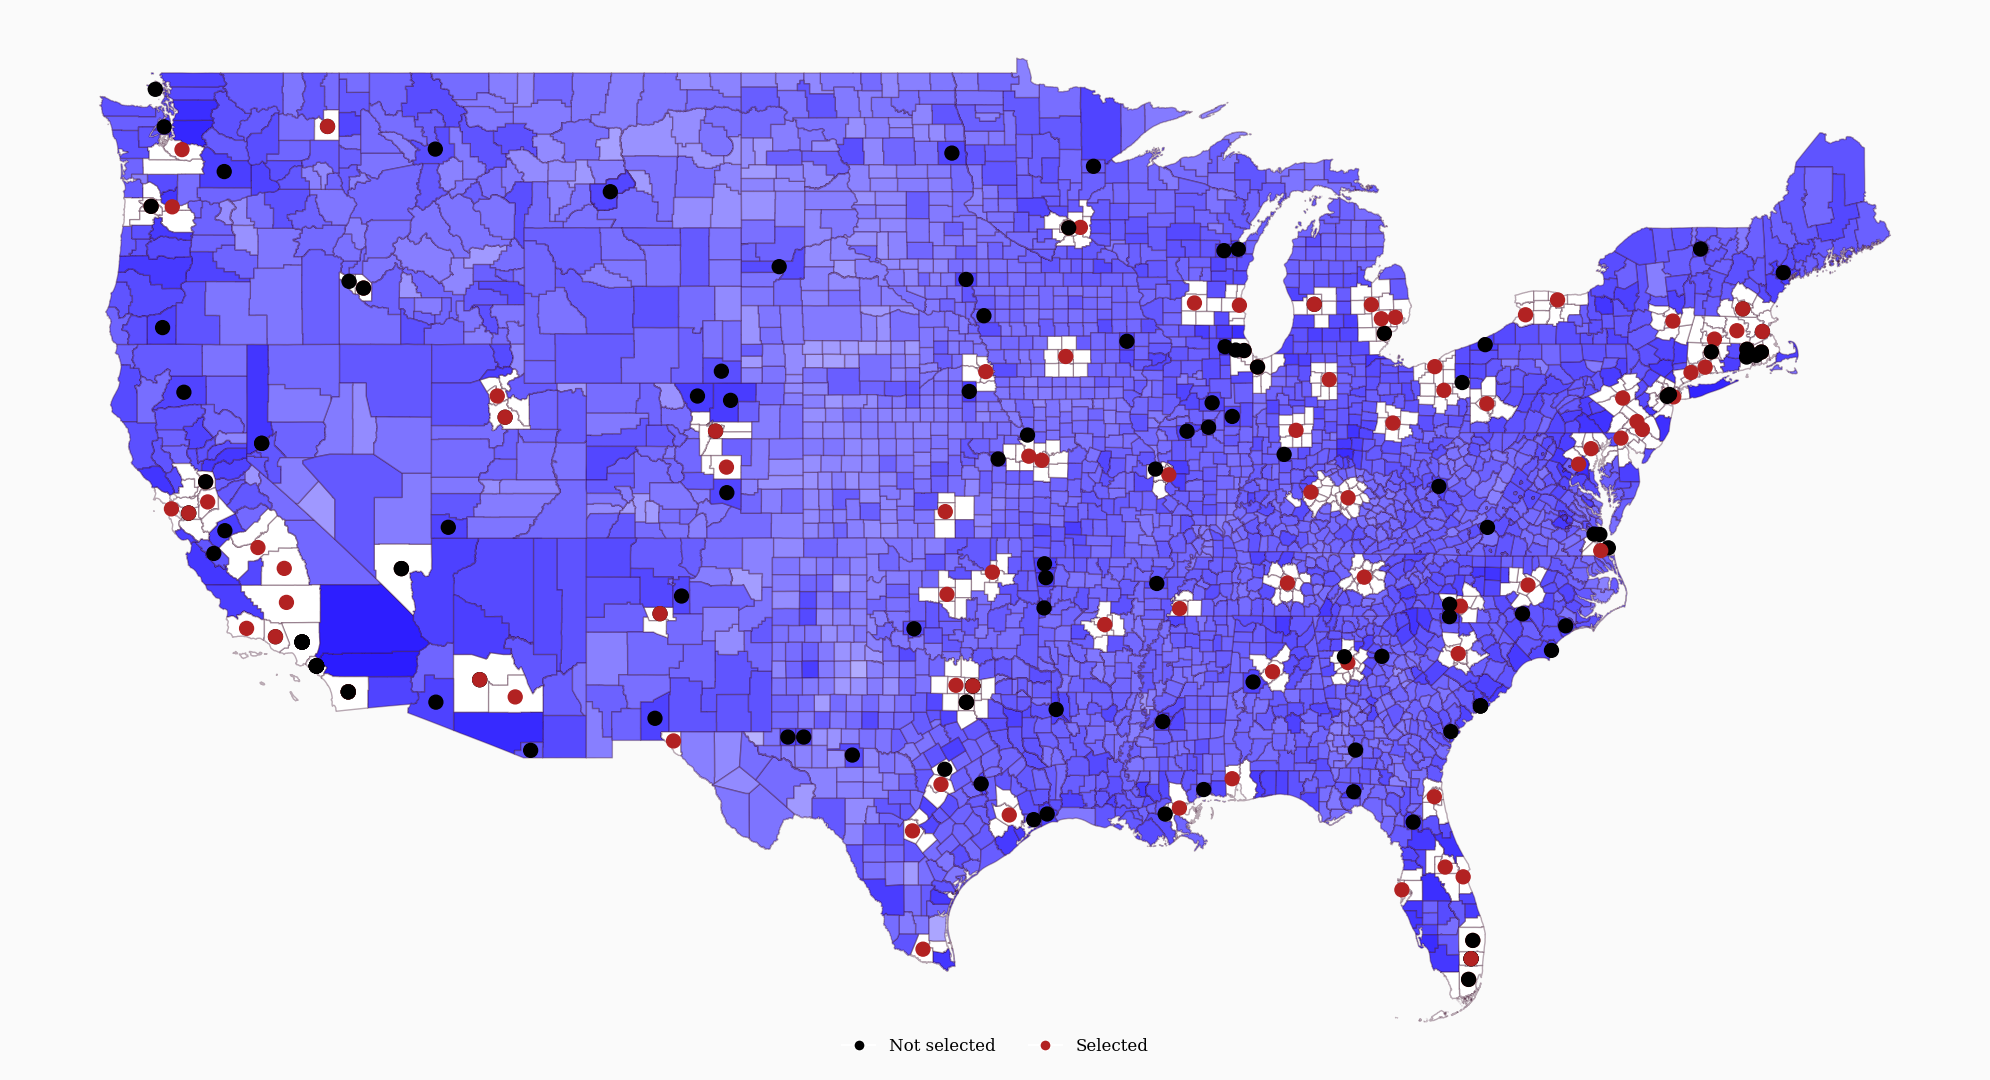

In [ ]:
facilities_VA = convertFacilities(x_df_VA)
visualizeMap(z_df_VA, facilities_VA)

# Takeaways

1. Binary decision variables are an extremely powerful modeling tool that allow us to capture yes/no decisions. GLPK and Gurobi can solve models with binary decision variables, though at a computational cost compared to continuous linear models.
2. Particularly in problems that significantly impact peoples' lives and health, always analyze your models assumptions and re-assess if needed.

### Extra practice:

What are some potential weaknesses of the final model we built (including vaccine allocation decisions)? How could you change the model to better capture the dynamics of the real world problem?

Ask yourself:
- Are there any unnecessary or unrealistic restrictions placed on our facility building decisions?
- Does the objective capture all of the costs we care about?
- Are there any ethical or practical concerns with how the vaccines are distributed in the current solution?
- Do we trust the inputs of the model?

